# Clasificación por vecinos más cercanos

Para este punto, se usan los datos del fichero penguins.csv que se encuentra en el repositorio de datos de seaborn, en los cuales se encuentran los datos de alturas, anchuras y masas de pinguinos, y su especie. El primer paso es definir las funciones necesarias, entre las cuales se crearon las funciones normalizar_cols y normalizar_total para normalizar los datos, la función euclidiana n-dimensional para calcular la distancia euclidiana entre dos puntos, y la función knn para calcular la clasificación por vecinos más cercanos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def normalizar_cols(df, cols):
    for i in cols:
        try:
            max_i = df[i].max()
            min_i = df[i].min()
            df[i] = (df[i] - min_i) / (max_i - min_i)
        except Exception:
            pass
    return df

def normalizar_total(df, cols):
    max_i = df[cols].max().max()
    min_i = df[cols].min().min()
    df[cols] = (df[cols] - min_i) / (max_i - min_i)
    return df

def euclidiana(x0, x1):
    suma = 0
    for i in zip(x0, x1):
        suma += (i[0] - i[1]) ** 2
    return np.sqrt(suma)

def knn(df, k_punto, ejes, categoria, vecinos=5):
    """
    Calcula los K vecinos más cercanos y retorna la categoría más frecuente.
    """
    df_parcial = df[ejes + [categoria]].copy()
    df_parcial['distancia'] = df_parcial.apply(lambda x: euclidiana(x[ejes], k_punto), axis=1)
    df_parcial = df_parcial.sort_values(by='distancia')
    df_parcial = df_parcial.head(vecinos)
    frecuencias = df_parcial[categoria].value_counts()
    return frecuencias.index[0]

## Carga de datos

In [2]:
df = sns.load_dataset('penguins').dropna()
df.head(2)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female


### Selección de datos

Se seleccionan los datos de pinguinos para este ejemplo, los cuales van a ser clasificados por especie, se divide el dataset en un 80% para entrenamiento y 20% para pruebas, y se normalizan las columnas de interés por columnas, de esta forma el peso de cada variable es equivalente.

In [3]:
categorias=df['species'].unique()
categoria_col='species'
cols_3d=['bill_length_mm', 'bill_depth_mm', 'body_mass_g']

df=normalizar_cols(df, cols_3d)

train = df.sample(frac=0.8)
test = df.drop(train.index)

colores ={}
colores_name=['red','green','blue']
for i in categorias:
    colores[i]=colores_name.pop()


### Evaluación de la predicción
Debido a la separación de los datos, los grupos formados son muy discriminados, esto facilita la clasificación, y permite tener un alto nivel de acertividad en la predicción.

In [8]:
test['predicho']=test[cols_3d].apply(lambda x: knn(train, x, cols_3d, categoria_col, vecinos=7), axis=1)

cm = pd.crosstab(test[categoria_col], test['predicho'])
cm

predicho,Adelie,Chinstrap,Gentoo
species,,,
Adelie,32,0,0
Chinstrap,1,13,0
Gentoo,0,0,21


In [9]:
test[test['predicho']!=test['species']]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,predicho
206,Chinstrap,Dream,0.378182,0.5,187.0,0.180556,Female,Adelie


In [6]:
!pip install ipympl

### Presentación
Como ultimo paso, se presentan los resultados del algoritmo KNN, en un grafico 3D, con el cual se puede interactuar al usar el elemento **%matplotlib widget**

/tmp/ipykernel_20592/719524266.py:24: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(df_pred_incorr[cols_3d[0]], df_pred_incorr[cols_3d[1]], df_pred_incorr[cols_3d[2]],


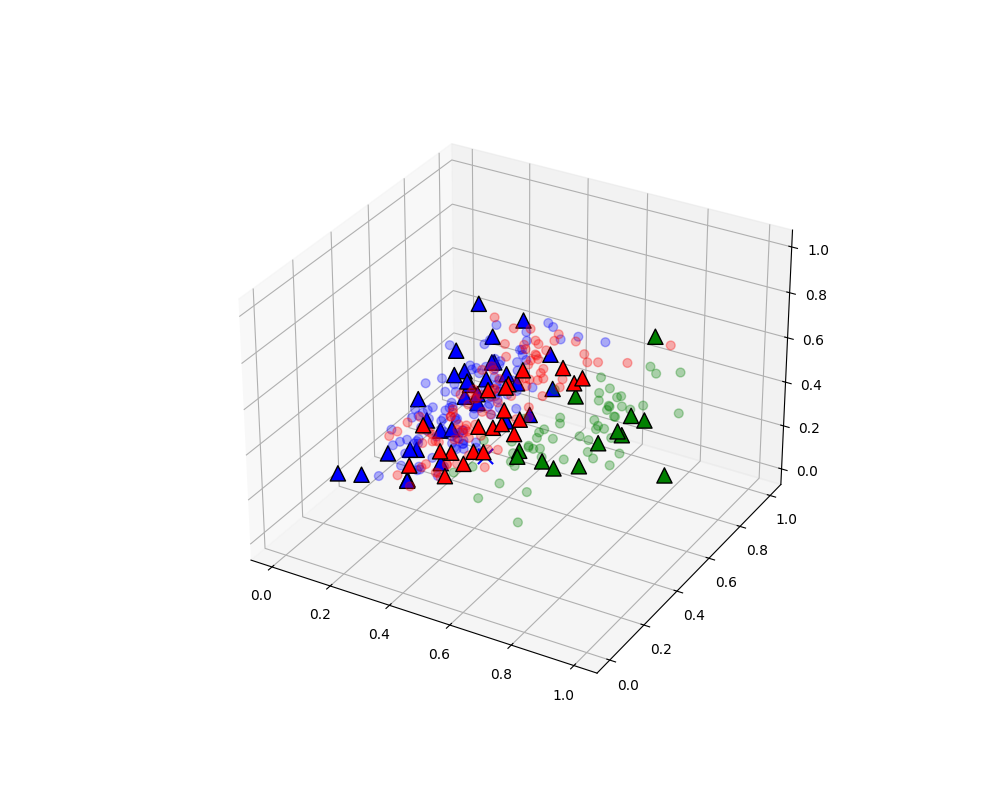

In [10]:
%matplotlib widget
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection='3d')
for cat in categorias:
    color = colores.get(cat, 'gray')  # Color gris por defecto si hay más categorías
    
    # Filtrar puntos de esta categoría
    df_orig = train[train[categoria_col] == cat]
    df_pred = test[test['predicho'] == cat]
    
    # Puntos iniciales: forma de círculo ('o'), menor opacidad para no saturar
    ax.scatter(df_orig[cols_3d[0]], df_orig[cols_3d[1]], df_orig[cols_3d[2]], 
                color=color, marker='o', s=40, alpha=0.3, 
                label=f'Inicial - Cat {cat}')
    
    if not df_pred.empty:
        df_pred_corr=df_pred[df_pred['predicho']==df_pred['species']]
        df_pred_incorr=df_pred[df_pred['predicho']!=df_pred['species']]
        if not df_pred_corr.empty:
            ax.scatter(df_pred_corr[cols_3d[0]], df_pred_corr[cols_3d[1]], df_pred_corr[cols_3d[2]], 
                        color=color, marker='^', s=120, alpha=1.0, edgecolor='black', 
                        label=f'Predicho - Cat {cat}')
        if not df_pred_incorr.empty:
            ax.scatter(df_pred_incorr[cols_3d[0]], df_pred_incorr[cols_3d[1]], df_pred_incorr[cols_3d[2]], 
                        color=color, marker='x', s=120, alpha=1.0, edgecolor='black', 
                        label=f'Predicho - Cat {cat}')